In [ ]:
#  IMPORTING THE LIBRARIES
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense,Dropout, Flatten
# Dropout Reguralization : To get rid of Overfitting Problem
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as k


In [ ]:
# Number of classes
num_classes=10

In [ ]:
# Sizes of the batch # epochs
batch_size= 64
epochs =24

In [ ]:
# input image dimension
img_rows, img_cols =28, 28

In [ ]:
# the data ,shuffled and split between train and test
(x_train,y_train), (x_test,y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_test.shape

(10000, 28, 28)

In [ ]:
len(y_train)

60000

In [ ]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [ ]:
x_train.shape[0]

60000

In [ ]:
x_train = x_train.reshape(x_train.shape[0], img_rows,img_cols,1)
x_test = x_test.reshape(x_test.shape[0], img_rows,img_cols,1)
input_shape = (img_rows,img_cols,1)

In [ ]:
input_shape

(28, 28, 1)

In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
# Type convert and scale the test and training data
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255.
x_test /= 255.
print('x_train shape:', x_train.shape)
print('x_test.shape:', x_test.shape)
print(y_train[0:3])

x_train shape: (60000, 28, 28, 1)
x_test.shape: (10000, 28, 28, 1)
[9 0 0]


In [ ]:
# Convert Class Vectors To Binary Matrices. One-hot encoding
# 3 => 0 0 0 1 0 0 0 0 0 0 & 1=> 0 1 0 0 0 0 0 0 0 0 0
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)
print(y_train[0:2])
...# Verify Once Encoding

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


Ellipsis

In [ ]:
# Define the model
model = Sequential()

In [ ]:
num_classes

10

In [ ]:
# Create a CNN to classify the Images
model.add(Conv2D(32, kernel_size = (3,3),
                activation='relu',
                input_shape = input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Define Compile to minimize categorical loss, use some optimizer to optimize , and optimize the maximizing accuracy
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])

In [ ]:
# Train the model test/validate the mode with the test data after each cycle(epoch)  through the training data
# Return history of the loss and accuracy for each epoch
hist = model.fit(x_train,y_train,
                 batch_size=64,
                 epochs=24,
                 verbose=1,
                 validation_data = (x_test,y_test))

Epoch 1/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.5852 - loss: 1.0978 - val_accuracy: 0.7129 - val_loss: 0.7298
Epoch 2/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7470 - loss: 0.6612 - val_accuracy: 0.7610 - val_loss: 0.6320
Epoch 3/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7815 - loss: 0.5810 - val_accuracy: 0.7908 - val_loss: 0.5707
Epoch 4/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8113 - loss: 0.5183 - val_accuracy: 0.8136 - val_loss: 0.5246
Epoch 5/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8325 - loss: 0.4707 - val_accuracy: 0.8304 - val_loss: 0.4723
Epoch 6/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.8446 - loss: 0.4381 - val_accuracy: 0.8445 - val_loss: 0.4441
Epoch 7/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8532 - loss: 0.4129 - val_accuracy: 0.8388 - val_loss: 0.4554
Epoch 8/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8596 - loss: 0.3935 - 

In [ ]:
hist.history

{'accuracy': [0.5852000117301941,
  0.7470166683197021,
  0.7814666628837585,
  0.8112999796867371,
  0.8324833512306213,
  0.8446333408355713,
  0.8532333374023438,
  0.8596166372299194,
  0.8651166558265686,
  0.8696333169937134,
  0.8732666373252869,
  0.8768666386604309,
  0.8804166913032532,
  0.8827833533287048,
  0.8854166865348816,
  0.8873166441917419,
  0.8888333439826965,
  0.8907833099365234,
  0.8930166959762573,
  0.8922500014305115,
  0.896049976348877,
  0.897599995136261,
  0.8974999785423279,
  0.8992833495140076],
 'loss': [1.0978285074234009,
  0.6612288355827332,
  0.5810258984565735,
  0.5183066725730896,
  0.4706606864929199,
  0.43810591101646423,
  0.41292431950569153,
  0.3934870958328247,
  0.37698879837989807,
  0.36443325877189636,
  0.3538167178630829,
  0.34151166677474976,
  0.3340659439563751,
  0.3253883123397827,
  0.3174948990345001,
  0.31310129165649414,
  0.30565059185028076,
  0.30037087202072144,
  0.29425907135009766,
  0.29284802079200745,
  0

In [ ]:
# Evaluate the model with the test data to get the scores on "real data"
score = model.evaluate(x_test,y_test,verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.31587693095207214
Test accuracy: 0.8855000138282776


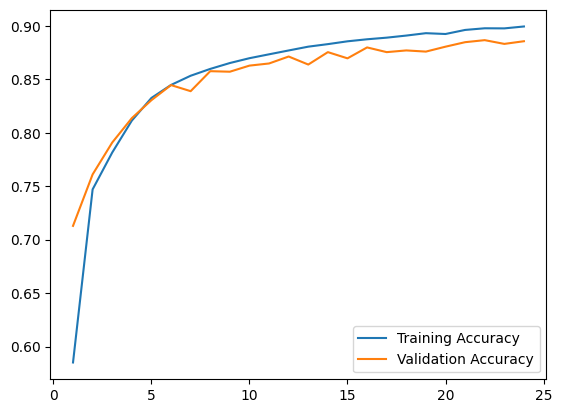

In [ ]:
# Plot data to see relationship in training and validation data
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
epoch_list = list(range(1, len(hist.history['accuracy'])+1))
plt.plot(epoch_list, hist.history['accuracy'], epoch_list,hist.history['val_accuracy'])
plt.legend(('Training Accuracy','Validation Accuracy'))
plt.show()
# values for x axis [1,2,..........n n0. of epochs]

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,104,736 (8.03 MB)

 Trainable params: 701,578 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,403,158 (5.35 MB)

In [ ]:
# Save Nreural Network Structure
from pathlib import path
model_structure = model . to_json()
f = path ("")
f.write_text(model_structure)

# Save The Trained Weights
model.save_weights("")
